# Policy-Grid Demonstrations for the UVIF Conceptual Framework

Companion code for the manuscript

> **Variational Equilibrium in Cognitive Systems: A Conceptual Framework for Adaptive
> Viability**
> Habib Hamam, Faculty of Engineering, Université de Moncton.

---

### What this notebook is

A small, fully deterministic implementation of the five named contributions of the
framework — epistemic pull, protective shield, computational drag, action efficiency and
sustainability — as explicit functions of a policy and an environment state, with the
policy chosen by exhaustive search over a $51\times51$ grid.

It is an **illustrative demonstration of a stipulated toy model**. Two things follow that
must be stated before any result is read.

**It is scalar optimization.** The score maximized here is a weighted sum of scalar
benefits minus scalar costs, and the policy is a grid argmax of that sum. It is not a
numerical integration of the vector-field dynamics described in the manuscript. Nothing
computed here can demonstrate a departure from optimization, and Section 4 below shows
why directly.

**It does not test the manuscript's hypotheses.** Earlier versions of this notebook
reported the hypotheses H1 and H3 as supported. Both reports were wrong, for reasons given
in Sections 4 and 5, which reproduce the refutations rather than removing the claims
silently. Those sections are the substantive content of this notebook: they record what
the implementation cannot show, and what a valid test would require.

### What it does show

A horizon effect and a set of component-ablation contrasts within the stipulated model
(Sections 6 and 7). These illustrate how the model behaves. They are not evidence about
cognitive systems, and they do not discriminate the framework from the accounts the
manuscript compares itself with.

## 1. Setup

In [1]:
# ============================================================
# 1. Environment, output folders, reproducibility
# ============================================================
import os, json, itertools, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

PROJECT_NAME = "UVIF_CognitiveEquilibrium"

try:                                    # Colab
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/Outputs") / PROJECT_NAME
except Exception:                       # local / headless execution
    BASE_DIR = Path("Outputs") / PROJECT_NAME

FIG_DIR, TABLE_DIR, OTHER_DIR = BASE_DIR/"figures", BASE_DIR/"tables", BASE_DIR/"others"
for d in (FIG_DIR, TABLE_DIR, OTHER_DIR):
    d.mkdir(parents=True, exist_ok=True)

SUMMARY = BASE_DIR / "outputs_summary.txt"
SUMMARY.write_text("UVIF policy-grid demonstrations\n", encoding="utf-8")

def log(msg):
    print(msg)
    with open(SUMMARY, "a", encoding="utf-8") as f:
        f.write(str(msg) + "\n")

SEED = 20260916
RNG  = np.random.default_rng(SEED)

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})

log(f"[INFO] numpy {np.__version__} | seed {SEED}")
log(f"[INFO] outputs -> {BASE_DIR}")

[INFO] numpy 2.4.4 | seed 20260916
[INFO] outputs -> Outputs/UVIF_CognitiveEquilibrium


## 2. The five components and the scalar score

A policy is $\pi=(e,a)$: epistemic effort and action aggressiveness, both in $[0,1]$.
An environment state is $s=(R,T,H)$: resource level, threat level, horizon.

Each component is a function of $(\pi,s)$, and the environment enters **inside** those
functions — $1/R$ in the drag, $T$ in the protective term, $H$ in the sustainability term.
The score is their unit-weighted sum. This last fact is not incidental; it is what
Section 4 turns on.

In [2]:
# ============================================================
# 2. The five forces, the equilibrium objective, and policy search
# ============================================================
KAPPA = 3.0     # how fast information accrues with epistemic effort
LAM   = 0.35    # deliberation delay penalty on timeliness
CD    = 0.55    # unit cost of inference
RHO   = 0.90    # exposure to unrecoverable loss
CS    = 0.55    # per-step resource drawdown
REGEN = 0.30    # per-step resource replenishment
TAU_H = 25.0    # horizon over which unsustainability makes itself felt
RMIN  = 0.12    # floor so drag stays finite

def accuracy(e):
    """Belief quality attained by epistemic effort e."""
    return 0.5 + 0.45 * (1.0 - np.exp(-KAPPA * e))

def f_epistemic(e):
    """E_pull: information gained."""
    return 1.0 - np.exp(-KAPPA * e)

def f_action(e, a):
    """A_eff: timely, correct action. Deliberation delays it."""
    return a * (2.0 * accuracy(e) - 1.0) - LAM * e * a

def f_drag(e, R):
    """D_drag: cost of inference, which rises as resources deplete."""
    return CD * e ** 2 / np.maximum(R, RMIN)

def f_protect(e, a, T):
    """P_prot: probability-weighted unrecoverable loss.
    Aggressive action taken while poorly informed, under threat, is what
    endangers states the system cannot recover."""
    return RHO * a * T * (1.0 - accuracy(e))

def f_sustain(e, a, R, H):
    """S_sus: infeasibility of sustaining this policy over horizon H.

    A policy whose per-step drawdown exceeds replenishment is not viable
    indefinitely. The penalty saturates with the horizon: over a single
    episode an unsustainable policy costs almost nothing, which is precisely
    why a per-episode objective cannot express this force (prediction H2).
    """
    overdraw = np.maximum(0.0, CS * (e + a) - REGEN)
    return overdraw * (1.0 - np.exp(-H / TAU_H))

def uvif_objective(e, a, R, T, H, mask=(1, 1, 1, 1, 1)):
    """Net value at Variational Equilibrium. `mask` ablates individual forces (H4)."""
    mE, mA, mD, mP, mS = mask
    return (mE * f_epistemic(e)
            + mA * f_action(e, a)
            - mD * f_drag(e, R)
            - mP * f_protect(e, a, T)
            - mS * f_sustain(e, a, R, H))

# ----------------------------------------------------------------------------
# 2. Policy search on a fixed grid (deterministic, no optimiser stochasticity).
# ----------------------------------------------------------------------------
GRID = np.linspace(0.0, 1.0, 51)
EE, AA = np.meshgrid(GRID, GRID, indexing="ij")

def best_policy(R, T, H, mask=(1, 1, 1, 1, 1)):
    V = uvif_objective(EE, AA, R, T, H, mask)
    i, j = np.unravel_index(np.argmax(V), V.shape)
    return GRID[i], GRID[j], V[i, j]


# ---- Admissibility-constrained variant (used in Section 5) -------------------
P_MAX_DEFAULT = 0.15

def constrained_policy(R, T, H, p_max=P_MAX_DEFAULT):
    """Policy under a hard ceiling on exposure to unrecoverable loss."""
    V = f_epistemic(EE) + f_action(EE, AA) - f_drag(EE, R) - f_sustain(EE, AA, R, H)
    V = np.where(f_protect(EE, AA, T) <= p_max, V, -np.inf)
    i, j = np.unravel_index(np.argmax(V), V.shape)
    return GRID[i], GRID[j]

## 3. Environment set

The declared environment set is the full product grid: 9 resource levels × 5 threat levels
× 4 horizons = 180 environments. Sections 4 and 5 report exact policy agreement over all
180, so no calibration/evaluation split is involved in those results — they are algebraic
identities over the declared set, not fitted generalization estimates.

In [3]:
# ============================================================
# 3. The declared environment set
# ============================================================
R_ALL = np.round(np.linspace(0.20, 1.00, 9), 3)
T_ALL = np.round(np.linspace(0.10, 0.90, 5), 3)
H_ALL = np.array([5, 20, 60, 150], dtype=float)
ALLENV = np.array(list(itertools.product(R_ALL, T_ALL, H_ALL)), dtype=float)
log(f"[ENV] declared environments: {len(ALLENV)}  (9 x 5 x 4)")

[ENV] declared environments: 180  (9 x 5 x 4)


## 4. The implementation is a scalar optimization — a negative result

An earlier version of this notebook compared the model against a "fixed-weight
scalarization" comparator and reported that no fixed weights could reproduce its policies.
That comparison was invalid. The comparator did not merely fix the weights: it also
evaluated every component at a **fixed reference state** $(R_{\mathrm{ref}},
T_{\mathrm{ref}}, H_{\mathrm{ref}})$, so it could not respond to the environment at all.
What the comparison measured was state responsiveness, not fixed versus adaptive weighting.

The correct comparator keeps the weights fixed but lets the component functions see the
state — which is exactly what the model's own score already is, with all weights equal
to one. The test below is therefore expected to return exact agreement, and it does.

In [4]:
# ============================================================
# 4. Unit-weight scalarization over the same state-dependent components
# ============================================================
def unit_weight_scalarization(R, T, H):
    """Fixed (unit) weights, components evaluated at the ACTUAL state."""
    V = (1.0*f_epistemic(EE) + 1.0*f_action(EE, AA)
         - 1.0*f_drag(EE, R) - 1.0*f_protect(EE, AA, T) - 1.0*f_sustain(EE, AA, R, H))
    i, j = np.unravel_index(np.argmax(V), V.shape)
    return GRID[i], GRID[j]

agree = sum(1 for R, T, H in ALLENV
            if np.allclose(unit_weight_scalarization(R, T, H), best_policy(R, T, H)[:2]))
log(f"\n[SECTION 4] unit-weight scalarization reproduces the model policy: "
    f"{agree}/{len(ALLENV)} environments")
log("[SECTION 4] This is an identity, not a finding: the model's score IS a unit-weighted")
log("[SECTION 4] sum of the same state-dependent components. A fixed-weight scalar")
log("[SECTION 4] optimizer therefore reproduces every policy this implementation selects.")
log("[SECTION 4] CONSEQUENCE: this implementation cannot demonstrate any departure from")
log("[SECTION 4] scalar optimization, and the earlier H1 result is withdrawn.")


[SECTION 4] unit-weight scalarization reproduces the model policy: 180/180 environments
[SECTION 4] This is an identity, not a finding: the model's score IS a unit-weighted
[SECTION 4] sum of the same state-dependent components. A fixed-weight scalar
[SECTION 4] optimizer therefore reproduces every policy this implementation selects.
[SECTION 4] CONSEQUENCE: this implementation cannot demonstrate any departure from
[SECTION 4] scalar optimization, and the earlier H1 result is withdrawn.


**What a valid test would require.** To separate fixed from adaptive weighting, the
comparator must be a *state-aware* fixed-weight baseline — components evaluated at the
true state, weights constant and tuned under the same budget — and the model under test
must have weights that genuinely vary with state. This implementation has constant unit
weights, so it does not instantiate the distinction at all. Building that comparison
requires a different implementation, not a different analysis of this one.

## 5. A finite monotone penalty reproduces constrained choice — a second negative result

The manuscript previously claimed that choices under an admissibility ceiling on
unrecoverable loss cannot be reproduced by any monotone rescaling of utilities, and a
later version weakened this to any rescaling with a *finite* coefficient. Both claims are
false, and this notebook was the source of the error.

The earlier search ranged over power penalties $b\cdot\mathrm{loss}^{g}$ only. That family
cannot express a threshold, so widening $b$ drove the estimate to the search ceiling — an
artifact of the family, which was then misread as evidence that no finite penalty exists.
A hinge penalty is finite, monotone, and expresses a threshold directly.

In [5]:
# ============================================================
# 5. Hinge counterexample to the finite-penalty claim
# ============================================================
P_MAX = 0.15   # the admissibility ceiling used by the constrained model

def hinge_policy(b, thr, R, T, H):
    """Finite, monotone penalty on exposure above a threshold."""
    loss = f_protect(EE, AA, T)
    V = (f_epistemic(EE) + f_action(EE, AA) - f_drag(EE, R) - f_sustain(EE, AA, R, H)
         - b * np.maximum(0.0, loss - thr))
    i, j = np.unravel_index(np.argmax(V), V.shape)
    return GRID[i], GRID[j]

rows = []
for b in [2, 5, 10, 15, 20, 21, 22, 23, 30, 50]:
    m = sum(1 for R, T, H in ALLENV
            if np.allclose(hinge_policy(b, P_MAX, R, T, H), constrained_policy(R, T, H)))
    rows.append({"penalty coefficient b": b, "environments matched": f"{m}/{len(ALLENV)}",
                 "exact match": m == len(ALLENV)})
hinge_df = pd.DataFrame(rows)
hinge_df.to_csv(TABLE_DIR/"table_hinge_counterexample.csv", index=False)
log("\n[SECTION 5] finite monotone hinge penalty b*max(0, loss - 0.15) vs the constrained model:")
log(hinge_df.to_string(index=False))
display(hinge_df)

b_min = min(r["penalty coefficient b"] for r in rows if r["exact match"])
log(f"[SECTION 5] exact agreement over all {len(ALLENV)} environments from b = {b_min}.")
log("[SECTION 5] CONSEQUENCE: a finite monotone penalty reproduces the constrained")
log("[SECTION 5] policies exactly. The claim that none exists is withdrawn, in both its")
log("[SECTION 5] original and its finite-coefficient forms.")


[SECTION 5] finite monotone hinge penalty b*max(0, loss - 0.15) vs the constrained model:
 penalty coefficient b environments matched  exact match
                     2              175/180        False
                     5              176/180        False
                    10              177/180        False
                    15              178/180        False
                    20              178/180        False
                    21              179/180        False
                    22              180/180         True
                    23              180/180         True
                    30              180/180         True
                    50              180/180         True


,penalty coefficient b,environments matched,exact match
0,2,175/180,False
1,5,176/180,False
2,10,177/180,False
3,15,178/180,False
4,20,178/180,False
5,21,179/180,False
6,22,180/180,True
7,23,180/180,True
8,30,180/180,True
9,50,180/180,True


[SECTION 5] exact agreement over all 180 environments from b = 22.
[SECTION 5] CONSEQUENCE: a finite monotone penalty reproduces the constrained
[SECTION 5] policies exactly. The claim that none exists is withdrawn, in both its
[SECTION 5] original and its finite-coefficient forms.


The counterexample is exhaustive over the declared environment set and the $51\times51$
policy grid. It is not a proof about continuous policy spaces — but it does not need to be:
a single finite monotone penalty that matches everywhere is sufficient to refute a
universal negative claim.

## 6. Horizon dependence — an illustration, not a discriminating test

The sustainability component contains the horizon $H$ explicitly, so a policy difference
between short and long horizons is a consequence of how the score was stipulated. It is
shown here because it makes the model's behaviour concrete, not because it distinguishes a
sustainability *force* from a long-horizon *utility term*. Those two formulations are not
separated by anything computed here.


[SECTION 6] short-horizon policy (e,a) = (0.52, 1.00), score 0.984805
[SECTION 6] long-horizon  policy (e,a) = (0.38, 0.16), score 0.610518
[SECTION 6] deterministic resource drift of the long-horizon policy: +0.0030 per step
[SECTION 6] resource failure step: short-horizon 1, long-horizon None
[SECTION 6] Both are consequences of the stipulated sustainability term.


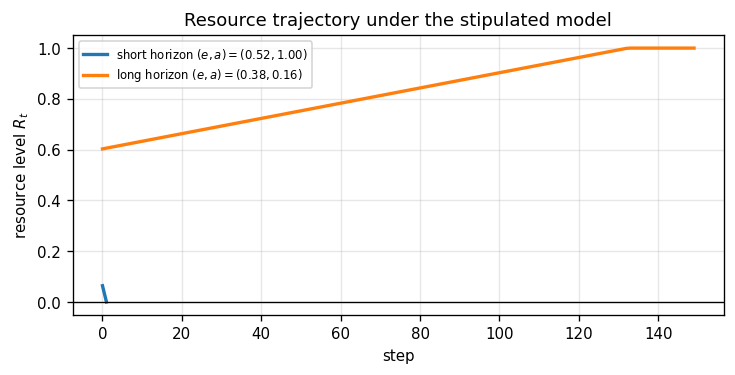

In [6]:
# ============================================================
# 6. Horizon contrast under the stipulated score
# ============================================================
def rollout(e, a, R0=0.6, steps=150):
    """Deterministic resource trajectory. Returns the path and the failure step (or None)."""
    R, traj, fail = R0, [], None
    for t in range(steps):
        R = min(1.0, R + REGEN - CS*(e + a))
        if R <= 0:
            traj.append(0.0); fail = t; break
        traj.append(R)
    return np.array(traj), fail

e_s, a_s, v_s = best_policy(0.6, 0.5, 1.0)
e_l, a_l, v_l = best_policy(0.6, 0.5, 150.0)
traj_s, fail_s = rollout(e_s, a_s)
traj_l, fail_l = rollout(e_l, a_l)
drift_l = REGEN - CS*(e_l + a_l)

log(f"\n[SECTION 6] short-horizon policy (e,a) = ({e_s:.2f}, {a_s:.2f}), score {v_s:.6f}")
log(f"[SECTION 6] long-horizon  policy (e,a) = ({e_l:.2f}, {a_l:.2f}), score {v_l:.6f}")
log(f"[SECTION 6] deterministic resource drift of the long-horizon policy: {drift_l:+.4f} per step")
log(f"[SECTION 6] resource failure step: short-horizon {fail_s}, long-horizon {fail_l}")
log("[SECTION 6] Both are consequences of the stipulated sustainability term.")

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.plot(traj_s, lw=2, label=f"short horizon $(e,a)=({e_s:.2f},{a_s:.2f})$")
ax.plot(traj_l, lw=2, label=f"long horizon $(e,a)=({e_l:.2f},{a_l:.2f})$")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("step"); ax.set_ylabel("resource level $R_t$")
ax.set_title("Resource trajectory under the stipulated model")
ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG_DIR/"figure_horizon_contrast.png", bbox_inches="tight")
plt.show()

## 7. Component ablations — corrected scoring and complete coverage

Two defects in the earlier version of this analysis are fixed here.

**Scoring.** Previously, once a trajectory lost viability the remaining steps were filled
with `last_value - 1`. That put an assigned number into a reported curve. Nothing is
assigned now: each ablation reports the mean score **over viable steps only**, and the
viability-failure step separately. A run that fails early is described by when it failed,
not by an invented score for steps that never happened.

**Coverage.** Previously four of the five components were ablated; action efficiency was
never removed. All five are ablated here.

Ablated agents are still scored with the intact score, so an agent is judged by what its
behaviour costs under the full set of stated considerations rather than by its own
truncated objective.

In [7]:
# ============================================================
# 7. Single-component ablations, all five, no assigned post-failure values
# ============================================================
MASKS = {"intact":              (1,1,1,1,1),
         "no epistemic pull":   (0,1,1,1,1),
         "no action efficiency":(1,0,1,1,1),
         "no drag":             (1,1,0,1,1),
         "no protection":       (1,1,1,0,1),
         "no sustainability":   (1,1,1,1,0)}

def ablation_run(mask, envs, steps=150, R0=0.6):
    means, fails = [], []
    for R, T, _H in envs:
        H = float(steps)
        Rt, vals, fail = R0, [], None
        e, a, _ = best_policy(Rt, T, H, mask)
        for t in range(steps):
            vals.append(uvif_objective(e, a, max(Rt, 1e-6), T, H))   # intact scoring
            Rt = min(1.0, Rt + REGEN - CS*(e + a))
            if Rt <= 0:
                fail = t; break
            e, a, _ = best_policy(Rt, T, H, mask)
        means.append(np.mean(vals)); fails.append(fail)
    viable = [f is None for f in fails]
    failed = [f for f in fails if f is not None]
    return (float(np.mean(means)), float(np.mean(viable))*100,
            (float(np.mean(failed)) if failed else None), len(envs))

rows = []
for name, m in MASKS.items():
    mean_v, pct_viable, mean_fail, n = ablation_run(m, ALLENV[:36])
    rows.append({"ablation": name,
                 "mean score over viable steps": round(mean_v, 3),
                 "% runs viable to 150 steps": round(pct_viable, 1),
                 "mean failure step (failed runs)": ("--" if mean_fail is None else round(mean_fail, 1))})
abl_df = pd.DataFrame(rows)
abl_df.to_csv(TABLE_DIR/"table_component_ablations.csv", index=False)
log("\n[SECTION 7] single-component ablations (36 environments, intact scoring,")
log("[SECTION 7] no values assigned after viability failure):")
log(abl_df.to_string(index=False))
display(abl_df)


[SECTION 7] single-component ablations (36 environments, intact scoring,
[SECTION 7] no values assigned after viability failure):
            ablation  mean score over viable steps  % runs viable to 150 steps mean failure step (failed runs)
              intact                         0.598                       100.0                              --
   no epistemic pull                         0.497                       100.0                              --
no action efficiency                         0.638                       100.0                              --
             no drag                         0.063                         0.0                            74.0
       no protection                         0.499                       100.0                              --
   no sustainability                         0.302                         0.0                             1.0


,ablation,mean score over viable steps,% runs viable to 150 steps,mean failure step (failed runs)
0,intact,0.598,100.0,--
1,no epistemic pull,0.497,100.0,--
2,no action efficiency,0.638,100.0,--
3,no drag,0.063,0.0,74.0
4,no protection,0.499,100.0,--
5,no sustainability,0.302,0.0,1.0


Two features of this table should not be passed over.

**Removing action efficiency raises the mean score.** The ablated agent scores above the
intact one while remaining fully viable. Since the ablated agent is judged by the intact
score, this says the intact agent's own greedy per-step choice is not the best policy for
the score it is being graded on. That is a defect of the model as specified, not a finding
about cognition, and it undercuts any reading of these ablations as showing that each
component "earns its place."

**Two ablations fail by different routes.** Removing drag loses viability late through
runaway inference cost; removing sustainability loses it almost immediately. The contrast
is real within the model, but it follows from which term was deleted from a stipulated
sum, and is not evidence that a cognitive system lacking these considerations degrades in
these ways.

The outcomes reported here are a single composite score plus a viability indicator.
A substantive evaluation would report independent safety and resource measurements, and
would retune each ablated agent rather than scoring it under settings chosen for the
intact one.

## 8. Sensitivity — and its limits

Each of the six model constants is varied by $\pm40\%$, one at a time, and three
qualitative properties are re-checked. The scope of this sweep should be read precisely:
it covers six constants individually, not jointly; it does not vary the policy-grid
resolution, the environment ranges, the ablation set or the penalty families of Sections 4
and 5; and it re-checks three properties rather than every statement in this notebook.

In [8]:
# ============================================================
# 8. One-at-a-time sensitivity over the model constants
# ============================================================
BASE = dict(KAPPA=KAPPA, LAM=LAM, CD=CD, RHO=RHO, CS=CS, REGEN=REGEN)

def properties_under(**over):
    g = globals(); saved = {k: g[k] for k in BASE}
    g.update(over)
    try:
        pols = np.array([best_policy(R, T, H)[:2] for R, T, H in ALLENV])
        p1 = len(np.unique(pols, axis=0)) > 1                       # policy varies with state
        s = best_policy(0.6, 0.5, 1.0)[:2]; l = best_policy(0.6, 0.5, 150.0)[:2]
        p2 = (l[0] + l[1]) < (s[0] + s[1])                          # longer horizon, less draw
        a_int = ablation_run(MASKS["intact"], ALLENV[:12])[1]
        a_sus = ablation_run(MASKS["no sustainability"], ALLENV[:12])[1]
        p3 = a_sus < a_int                                          # ablation lowers viability
        return p1, p2, p3
    finally:
        g.update(saved)

rows = []
for name, base in BASE.items():
    for mult, tag in ((0.6, "-40%"), (1.0, "base"), (1.4, "+40%")):
        p1, p2, p3 = properties_under(**{name: base*mult})
        rows.append({"constant": name, "setting": tag, "value": round(base*mult, 3),
                     "policy varies with state": p1,
                     "longer horizon draws less": p2,
                     "sustainability ablation lowers viability": p3})
sens = pd.DataFrame(rows)
sens.to_csv(TABLE_DIR/"table_sensitivity.csv", index=False)
log("\n[SECTION 8] one-at-a-time sensitivity (+/-40%):")
log(sens.to_string(index=False))
display(sens)
cols = ["policy varies with state","longer horizon draws less","sustainability ablation lowers viability"]
log("[SECTION 8] held in all settings: " + (", ".join(c for c in cols if sens[c].all()) or "none"))
log("[SECTION 8] failed somewhere:     " + (", ".join(c for c in cols if not sens[c].all()) or "none"))
for c in cols:
    if not sens[c].all():
        bad = sens.loc[~sens[c], ["constant","setting","value"]].to_dict("records")
        log(f"[SECTION 8] '{c}' fails at: " + "; ".join(f"{r['constant']}={r['value']} ({r['setting']})" for r in bad))


[SECTION 8] one-at-a-time sensitivity (+/-40%):
constant setting  value  policy varies with state  longer horizon draws less  sustainability ablation lowers viability
   KAPPA    -40%   1.80                      True                       True                                      True
   KAPPA    base   3.00                      True                       True                                      True
   KAPPA    +40%   4.20                      True                       True                                      True
     LAM    -40%   0.21                      True                       True                                      True
     LAM    base   0.35                      True                       True                                      True
     LAM    +40%   0.49                      True                       True                                      True
      CD    -40%   0.33                      True                       True                                      True

,constant,setting,value,policy varies with state,longer horizon draws less,sustainability ablation lowers viability
0,KAPPA,-40%,1.80,True,True,True
1,KAPPA,base,3.00,True,True,True
2,KAPPA,+40%,4.20,True,True,True
3,LAM,-40%,0.21,True,True,True
4,LAM,base,0.35,True,True,True
5,LAM,+40%,0.49,True,True,True
6,CD,-40%,0.33,True,True,True
7,CD,base,0.55,True,True,True
8,CD,+40%,0.77,True,True,True
9,RHO,-40%,0.54,True,True,True


[SECTION 8] held in all settings: policy varies with state, longer horizon draws less
[SECTION 8] failed somewhere:     sustainability ablation lowers viability
[SECTION 8] 'sustainability ablation lowers viability' fails at: CS=0.33 (-40%)


The sweep does not come back clean, and that is reported rather than smoothed over: the
sustainability-ablation property fails at one setting. A property that holds at the chosen
constants but not under a moderate perturbation of one of them is a property of those
constants as much as of the model.

## 9. Summary

In [9]:
# ============================================================
# 9. What this notebook shows and does not show
# ============================================================
summary = pd.DataFrame([
 {"item": "Departure from scalar optimization",
  "status": "not shown",
  "detail": f"a unit-weight scalarization over the same state-dependent components "
            f"reproduces the model policy in {agree}/{len(ALLENV)} environments; the score "
            f"is itself such a sum"},
 {"item": "Irreversibility irreducible to a finite monotone penalty",
  "status": "refuted",
  "detail": f"the hinge penalty {b_min}*max(0, loss - {P_MAX}) reproduces the constrained "
            f"policy in {len(ALLENV)}/{len(ALLENV)} environments"},
 {"item": "Horizon dependence of the selected policy",
  "status": "shown, by stipulation",
  "detail": "the horizon enters the sustainability term explicitly; this does not separate "
            "a sustainability force from a long-horizon utility term"},
 {"item": "Distinct ablation signatures",
  "status": "shown for this model",
  "detail": "five single-component ablations differ in mean score and in viability; scored "
            "without assigned post-failure values"},
 {"item": "Evidence about cognitive systems",
  "status": "none",
  "detail": "the functional forms are stipulated by the author; nothing here is measured"},
])
summary.to_csv(TABLE_DIR/"table_summary.csv", index=False)
log("\n[SUMMARY]"); log(summary.to_string(index=False))
display(summary)

manifest = {"project": PROJECT_NAME, "seed": SEED, "n_environments": int(len(ALLENV)),
            "constants": {k: float(v) for k, v in BASE.items()}, "P_MAX": float(P_MAX),
            "hinge_b_exact_match": int(b_min),
            "unit_weight_agreement": f"{agree}/{len(ALLENV)}",
            "figures": sorted(p.name for p in FIG_DIR.glob("*.png")),
            "tables":  sorted(p.name for p in TABLE_DIR.glob("*.csv"))}
(OTHER_DIR/"manifest.json").write_text(json.dumps(manifest, indent=2))
log(f"\n[DONE] outputs written to {BASE_DIR}")


[SUMMARY]
                                                    item                status                                                                                                                                                   detail
                      Departure from scalar optimization             not shown a unit-weight scalarization over the same state-dependent components reproduces the model policy in 180/180 environments; the score is itself such a sum
Irreversibility irreducible to a finite monotone penalty               refuted                                                       the hinge penalty 22*max(0, loss - 0.15) reproduces the constrained policy in 180/180 environments
               Horizon dependence of the selected policy shown, by stipulation                    the horizon enters the sustainability term explicitly; this does not separate a sustainability force from a long-horizon utility term
                            Distinct ablation signatures  sho

,item,status,detail
0,Departure from scalar optimization,not shown,a unit-weight scalarization over the same stat...
1,Irreversibility irreducible to a finite monoto...,refuted,"the hinge penalty 22*max(0, loss - 0.15) repro..."
2,Horizon dependence of the selected policy,"shown, by stipulation",the horizon enters the sustainability term exp...
3,Distinct ablation signatures,shown for this model,five single-component ablations differ in mean...
4,Evidence about cognitive systems,none,the functional forms are stipulated by the aut...



[DONE] outputs written to Outputs/UVIF_CognitiveEquilibrium


## 10. Scope

This notebook implements a stipulated toy model and reports its behaviour. It does not
integrate the vector-field dynamics of the manuscript, does not test the manuscript's
hypotheses, and provides no evidence about biological or artificial cognitive systems.

Two claims previously made from this code — that the model departs from scalar
optimization, and that constrained choice under irreversibility cannot be reproduced by a
finite monotone penalty — are refuted by Sections 4 and 5 respectively. Both refutations
are exhaustive over the declared environment set and policy grid. They are retained here
because the earlier claims were published, and a correction that removed them without
recording what was wrong would leave readers unable to check the change.

A study that could support the manuscript's hypotheses would need, at minimum: a
state-aware fixed-weight baseline tuned under a matched budget; independent safety and
resource outcomes rather than a single composite score; held-out conditions with retuning
after each ablation; sensitivity over grid resolution and interacting parameters; and
comparators from the free-energy, resource-rational and constrained-control literatures
implemented on equal terms.